In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("covid-data.csv")

In [3]:
df.head()

,date,location,total_cases,new_deaths,stringency_index
0,01-01-2020,Germany,15895.0,319.0,8.409822
1,NaN,India,960.0,225.0,32.643358
2,03-01-2020,Germany,NaN,442.0,55.984431
3,04-01-2020,USA,54986.0,439.0,11.584386
4,05-01-2020,USA,6365.0,NaN,37.669536


In [4]:
df.tail()

,date,location,total_cases,new_deaths,stringency_index
995,22-09-2020,Germany,81549.0,476.0,84.373733
996,23-09-2020,France,60104.0,11.0,25.397487
997,24-09-2020,France,63081.0,294.0,3.111560
998,25-09-2020,Japan,84759.0,449.0,73.929474
999,26-09-2020,France,54653.0,223.0,10.634373


In [5]:
print("Rows: ",df.shape[0])
print("Column: ",df.shape[1])

Rows:  1000
Column:  5


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              950 non-null    str    
 1   location          950 non-null    str    
 2   total_cases       950 non-null    float64
 3   new_deaths        950 non-null    float64
 4   stringency_index  950 non-null    float64
dtypes: float64(3), str(2)
memory usage: 39.2 KB


In [7]:
df.columns.tolist()

['date', 'location', 'total_cases', 'new_deaths', 'stringency_index']

In [8]:
df.describe()

,total_cases,new_deaths,stringency_index
count,950.000000,950.000000,950.000000
mean,49418.931579,251.865263,49.451624
std,29088.865568,145.918777,28.251740
min,155.000000,0.000000,0.033251
25%,23636.500000,129.250000,24.016099
50%,50485.500000,258.500000,50.344755
75%,73787.500000,375.000000,73.676157
max,99935.000000,499.000000,99.707816


In [9]:
df.isnull().sum()

date                50
location            50
total_cases         50
new_deaths          50
stringency_index    50
dtype: int64

In [10]:
print("Duplicate Rows: ",df.duplicated().sum())

Duplicate Rows:  0


In [11]:
df = df.drop_duplicates()

In [12]:
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

In [13]:
print("Starting Date :", df["date"].min())
print("Ending Date :", df["date"].max())

Starting Date : 2020-01-01 00:00:00
Ending Date : 2020-12-30 00:00:00


In [14]:
print("Total Countries :", df["location"].nunique())

Total Countries : 6


In [15]:
df["location"].unique()

<StringArray>
['Germany', 'India', 'USA', 'Japan', nan, 'Brazil', 'France']
Length: 7, dtype: str

In [16]:
df = df.dropna()

In [17]:
df.isnull().sum()

date                0
location            0
total_cases         0
new_deaths          0
stringency_index    0
dtype: int64

In [18]:
print(df.shape)

(769, 5)


In [19]:
df = df.sort_values(by="date")

In [20]:
df = df.reset_index(drop=True)

In [21]:
df.head()

,date,location,total_cases,new_deaths,stringency_index
0,2020-01-01,Germany,15895.0,319.0,8.409822
1,2020-01-01,France,30454.0,187.0,53.869567
2,2020-01-01,Germany,18811.0,341.0,82.317402
3,2020-01-02,Germany,13943.0,300.0,52.415917
4,2020-01-03,USA,71826.0,97.0,84.804779


In [22]:
df["location"].unique()

<StringArray>
['Germany', 'France', 'USA', 'India', 'Brazil', 'Japan']
Length: 6, dtype: str

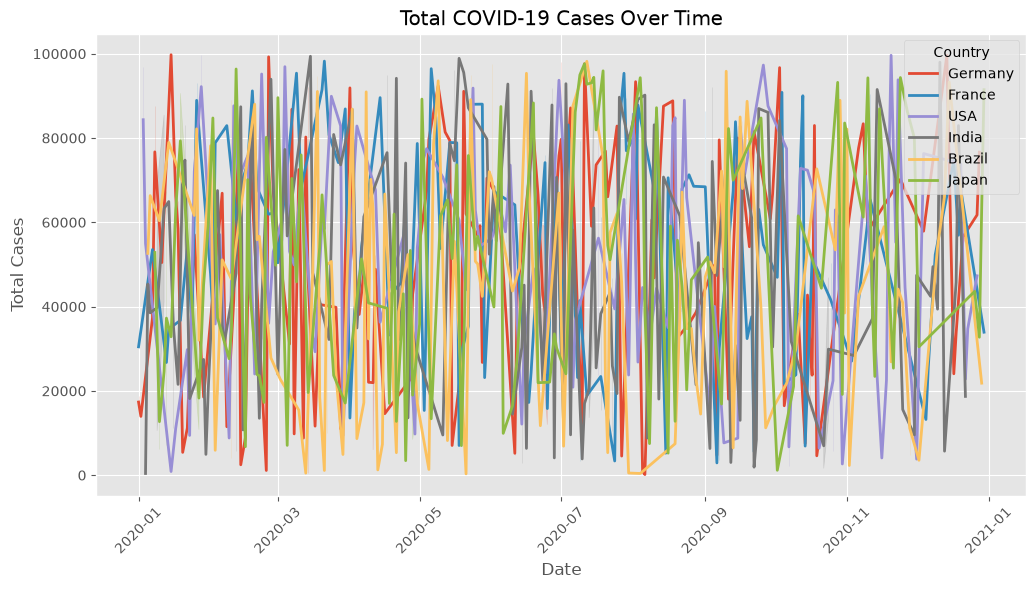

In [23]:
plt.figure(figsize=(12,6))

sns.lineplot(data=df, x="date", y="total_cases", hue="location", linewidth=2)

plt.title("Total COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)
plt.legend(title="Country")
plt.show()

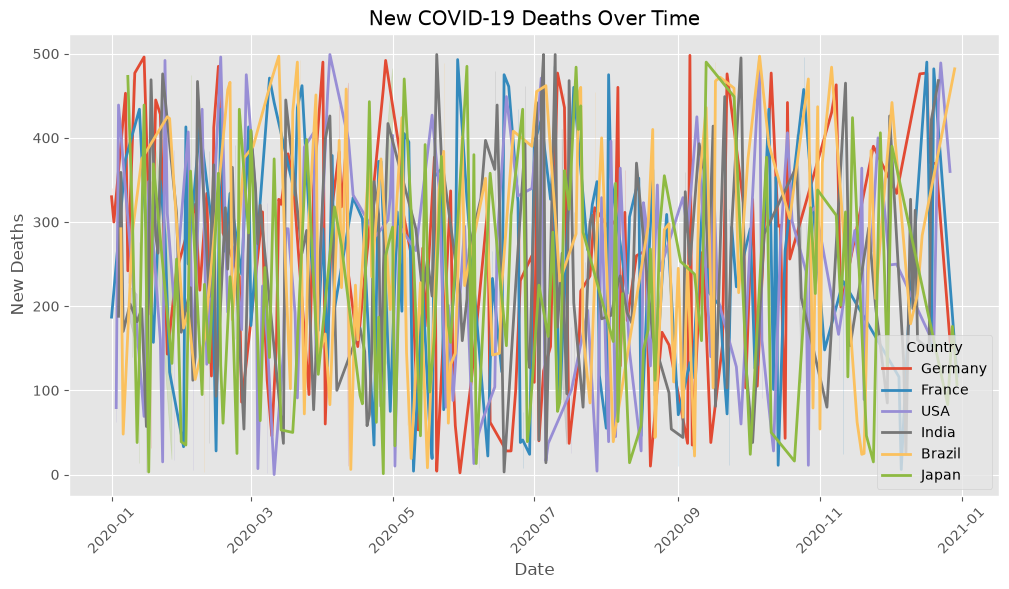

In [24]:
plt.figure(figsize=(12,6))

sns.lineplot(data=df, x="date", y="new_deaths", hue="location", linewidth=2)

plt.title("New COVID-19 Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("New Deaths")
plt.xticks(rotation=45)
plt.legend(title="Country")
plt.show()

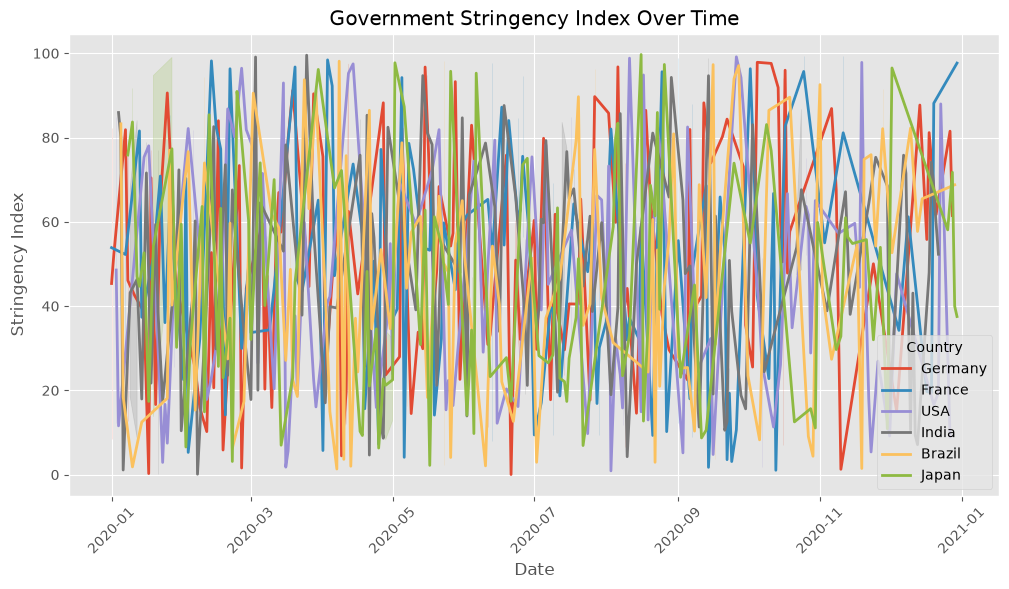

In [25]:
plt.figure(figsize=(12,6))

sns.lineplot(data=df, x="date", y="stringency_index", hue="location", linewidth=2)

plt.title("Government Stringency Index Over Time")
plt.xlabel("Date")
plt.ylabel("Stringency Index")
plt.xticks(rotation=45)
plt.legend(title="Country")
plt.show()

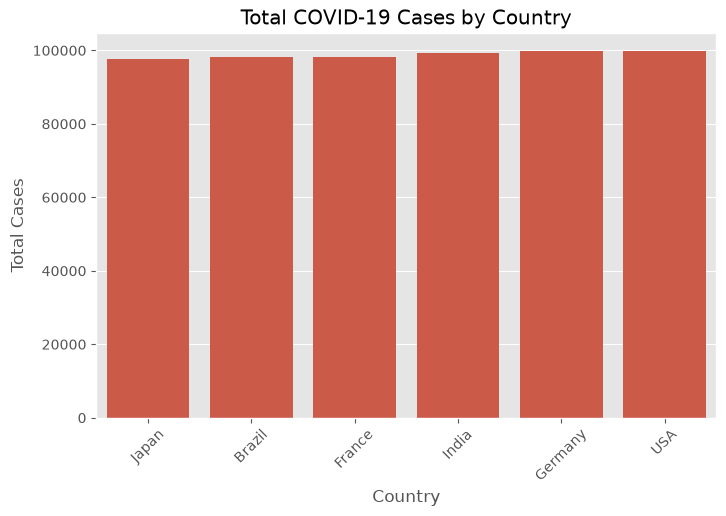

In [26]:
country_cases = df.groupby("location")["total_cases"].max().sort_values()

plt.figure(figsize=(8,5))

sns.barplot(x=country_cases.index, y=country_cases.values)

plt.title("Total COVID-19 Cases by Country")
plt.xlabel("Country")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)

plt.show()

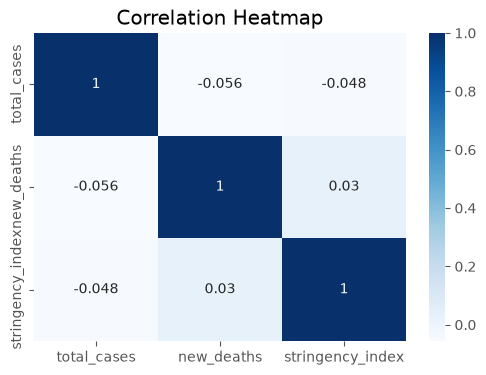

In [27]:
plt.figure(figsize=(6,4))

sns.heatmap(df[["total_cases","new_deaths","stringency_index"]].corr(),
            annot=True,
            cmap="Blues")

plt.title("Correlation Heatmap")
plt.show()

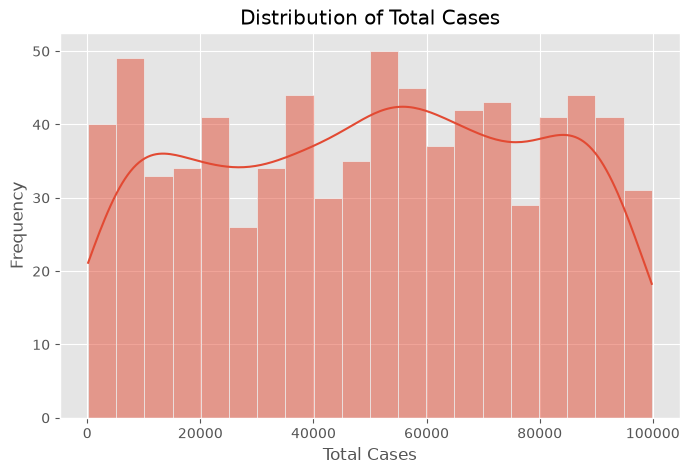

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df["total_cases"], bins=20, kde=True)

plt.title("Distribution of Total Cases")
plt.xlabel("Total Cases")
plt.ylabel("Frequency")

plt.show()

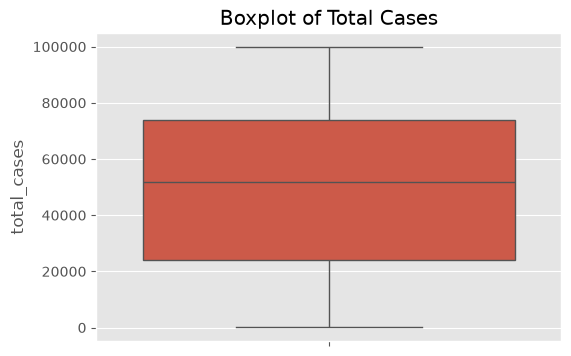

In [29]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["total_cases"])

plt.title("Boxplot of Total Cases")

plt.show()

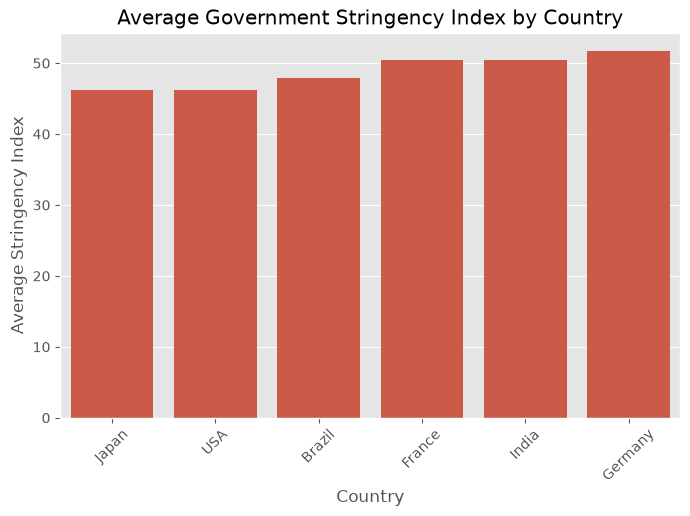

In [30]:
avg_stringency = df.groupby("location")["stringency_index"].mean().sort_values()

plt.figure(figsize=(8,5))

sns.barplot(x=avg_stringency.index, y=avg_stringency.values)

plt.title("Average Government Stringency Index by Country")
plt.xlabel("Country")
plt.ylabel("Average Stringency Index")
plt.xticks(rotation=45)

plt.show()

## 💡 Key Insight

While all six countries showed a **steady rise in total COVID-19 cases** over time, the **rate and scale of spread varied significantly** across nations — highlighting that local factors like population density, healthcare infrastructure, and public compliance mattered as much as government policy itself.

Interestingly, the correlation between the **government stringency index** and **new deaths** was found to be weak. This suggests that stricter lockdowns did not translate *immediately* into fewer deaths, likely due to a **lag effect** between policy implementation and its real-world impact on the case curve.

> 🔑 **Takeaway:** Government response strictness alone doesn't guarantee an immediate drop in deaths — timing and consistency of policy matter more than intensity alone.